In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df_main = pd.read_csv("../data/FINAL_GRAVITY_TRAINING_MATRIX.csv")

In [13]:
print(df_main.columns)

Index(['orig', 'dest', 'iso3_d', 'year', 'iso3_o', 'flow', 'P_it', 'PSR_i',
       'IMR_it', 'urban_it', 'LA_i', 'LL_i', 'P_jt', 'PSR_j', 'IMR_jt',
       'urban_jt', 'LA_j', 'LL_j', 'D_ij', 'LB_ij', 'OL_ij', 'COL_ij',
       't_2000', 't_2000_sq', 'flow_raw', 'log_flow_plus_1', 'ihs_flow',
       'is_migration', 'gdp_o', 'gdpcap_o', 'gdp_d', 'gdpcap_d', 'gdp_o_lag',
       'gdpcap_o_lag', 'gdp_d_lag', 'gdpcap_d_lag', 'log_gdp_o', 'log_gdp_d',
       'log_gdpcap_o', 'log_gdpcap_d', 'log_gdp_o_lag', 'log_gdp_d_lag',
       'log_gdpcap_o_lag', 'log_gdpcap_d_lag'],
      dtype='str')


In [39]:
len(df_main['gdp_o_lag']) - df_main['gdp_o_lag'].isna().sum() 

np.int64(181370)

In [16]:
# 1. Nombre d'années différentes
nb_annees = df_main['year'].nunique()

# 2. Nombre total de lignes
nb_lignes = len(df_main)  # ou df_main.shape[0]

# 3. Nombre de codes ISO numériques différents (Origine)
nb_iso = df_main['orig'].nunique()

print(f"Années distinctes      : {nb_annees}")
print(f"Nombre total de lignes : {nb_lignes:,}")
print(f"Codes ISO uniques      : {nb_iso}")

# Bonus : Voir quelles sont les années disponibles
print("Liste des années :", df_main['year'].unique())

Années distinctes      : 6
Nombre total de lignes : 231,702
Codes ISO uniques      : 200
Liste des années : [1990 1995 2000 2005 2010 2015]


In [17]:
df_main.describe()

,year,flow,P_it,PSR_i,IMR_it,urban_it,LA_i,LL_i,P_jt,PSR_j,...,gdp_d_lag,gdpcap_d_lag,log_gdp_o,log_gdp_d,log_gdpcap_o,log_gdpcap_d,log_gdp_o_lag,log_gdp_d_lag,log_gdpcap_o_lag,log_gdpcap_d_lag
count,231702.000000,2.317020e+05,2.305260e+05,230526.000000,230526.000000,223470.000000,2.216820e+05,221682.000000,2.305260e+05,230526.000000,...,1.813700e+05,1.813700e+05,219379.000000,219379.000000,219379.000000,219379.000000,181370.000000,181370.000000,181370.000000,181370.000000
mean,2002.678484,2.081389e+03,3.219853e+04,12.921031,0.034570,54.705575,6.913172e+05,0.190976,3.219853e+04,12.921031,...,2.171120e+11,8.569338e+06,23.609811,23.609811,14.959027,14.959027,23.451416,23.451416,14.832652,14.832652
std,8.557274,2.622785e+04,1.257884e+05,9.343252,0.034134,23.429676,1.928267e+06,0.393071,1.257884e+05,9.343252,...,9.573089e+11,1.330061e+07,2.332854,2.332854,1.584881,1.584881,2.331591,2.331591,1.592647,1.592647
min,1990.000000,0.000000e+00,6.215200e+01,2.344076,0.001258,5.274941,2.500000e+01,0.000000,6.215200e+01,2.344076,...,3.653429e+07,5.117174e+04,17.413762,17.413762,10.842943,10.842943,17.413762,17.413762,10.842943,10.842943
25%,1995.000000,0.000000e+00,1.344931e+03,6.373801,0.008751,35.186618,2.775000e+04,0.000000,1.344931e+03,6.373801,...,3.166000e+09,7.795643e+05,22.002214,22.002214,13.696178,13.696178,21.875735,21.875735,13.566490,13.566490
50%,2005.000000,0.000000e+00,6.216329e+03,12.514712,0.020598,55.389896,1.306700e+05,0.000000,6.216329e+03,12.514712,...,1.216006e+10,2.441765e+06,23.360350,23.360350,14.885437,14.885437,23.221422,23.221422,14.708232,14.708232
75%,2010.000000,3.700000e+01,2.029306e+04,16.672897,0.053804,73.438787,5.470260e+05,0.000000,2.029306e+04,16.672897,...,8.366979e+10,1.040792e+07,25.293115,25.293115,16.267584,16.267584,25.150144,25.150144,16.158077,16.158077
max,2015.000000,3.309139e+06,1.406848e+06,125.663414,0.225902,100.000000,1.707540e+07,1.000000,1.406848e+06,125.663414,...,1.504896e+13,1.106814e+08,30.532773,30.532773,18.522167,18.522167,30.342330,30.342330,18.522167,18.522167


In [18]:

df_main.info()

<class 'pandas.DataFrame'>
RangeIndex: 231702 entries, 0 to 231701
Data columns (total 44 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   orig              231702 non-null  str    
 1   dest              231702 non-null  str    
 2   iso3_d            230526 non-null  str    
 3   year              231702 non-null  int64  
 4   iso3_o            230526 non-null  str    
 5   flow              231702 non-null  int64  
 6   P_it              230526 non-null  float64
 7   PSR_i             230526 non-null  float64
 8   IMR_it            230526 non-null  float64
 9   urban_it          223470 non-null  float64
 10  LA_i              221682 non-null  float64
 11  LL_i              221682 non-null  float64
 12  P_jt              230526 non-null  float64
 13  PSR_j             230526 non-null  float64
 14  IMR_jt            230526 non-null  float64
 15  urban_jt          223470 non-null  float64
 16  LA_j              221682 non-nu

In [19]:
df_main.info()

<class 'pandas.DataFrame'>
RangeIndex: 231702 entries, 0 to 231701
Data columns (total 44 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   orig              231702 non-null  str    
 1   dest              231702 non-null  str    
 2   iso3_d            230526 non-null  str    
 3   year              231702 non-null  int64  
 4   iso3_o            230526 non-null  str    
 5   flow              231702 non-null  int64  
 6   P_it              230526 non-null  float64
 7   PSR_i             230526 non-null  float64
 8   IMR_it            230526 non-null  float64
 9   urban_it          223470 non-null  float64
 10  LA_i              221682 non-null  float64
 11  LL_i              221682 non-null  float64
 12  P_jt              230526 non-null  float64
 13  PSR_j             230526 non-null  float64
 14  IMR_jt            230526 non-null  float64
 15  urban_jt          223470 non-null  float64
 16  LA_j              221682 non-nu

In [20]:


# Nombre de pays uniques (en prenant l'union pour être sûr)
all_countries = set(df_main['orig'].unique()) | set(df_main['dest'].unique())
n = len(all_countries)

# Théorique par année (N * (N-1) si on exclut les flux vers soi-même)
theorie_annuelle = n * (n - 1)

print(f"Nombre de pays uniques : {n}")
print(f"Théorique par année : {theorie_annuelle} couples")

# Compte réel par année
coverage = df_main.groupby('year').size().to_frame('real_count')
coverage['theoretical'] = theorie_annuelle
coverage['pct_remplissage'] = (coverage['real_count'] / coverage['theoretical']) * 100

print("-" * 30)
print(coverage)

Nombre de pays uniques : 200
Théorique par année : 39800 couples
------------------------------
      real_count  theoretical  pct_remplissage
year                                          
1990       37830        39800        95.050251
1995       37830        39800        95.050251
2000       37830        39800        95.050251
2005       38612        39800        97.015075
2010       39800        39800       100.000000
2015       39800        39800       100.000000


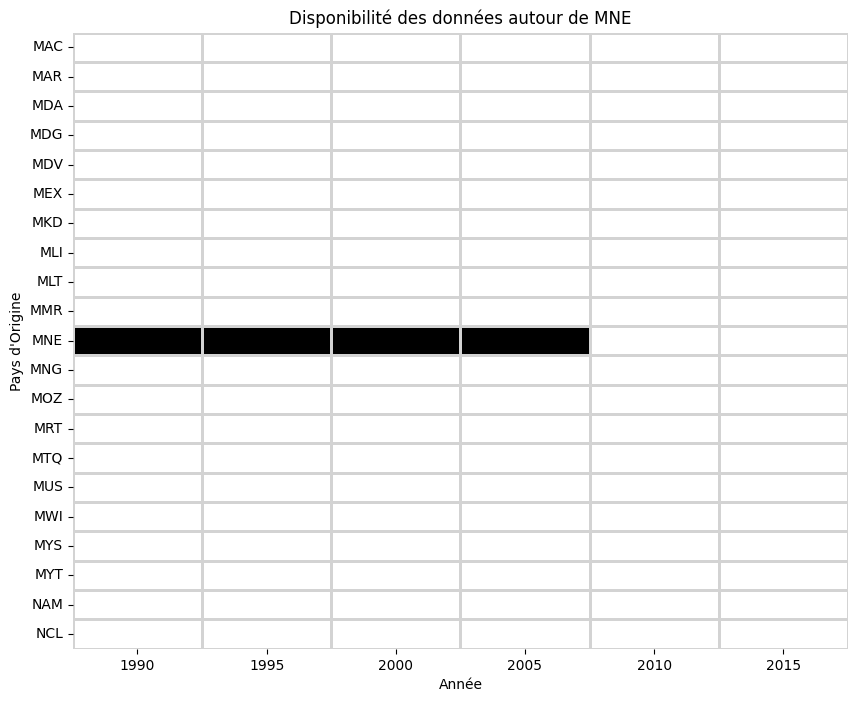

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

TARGET_COUNTRY = 'MNE'
WINDOW = 10

# Sélection des pays
pays_uniques = sorted(df_main['orig'].unique())
idx = pays_uniques.index(TARGET_COUNTRY)
subset = pays_uniques[max(0, idx - WINDOW) : min(len(pays_uniques), idx + WINDOW + 1)]

# Filtrage et Matrice
df_zoom = df_main[df_main['orig'].isin(subset)]
presence = pd.crosstab(df_zoom['orig'], df_zoom['year'])

# Graphique
plt.figure(figsize=(10, 8))
sns.heatmap(presence > 0, cbar=False, cmap="binary_r", linewidths=1, linecolor='lightgray', vmin=0, vmax=1)
plt.title(f"Disponibilité des données autour de {TARGET_COUNTRY}")
plt.xlabel("Année")
plt.ylabel("Pays d'Origine")
plt.yticks(rotation=0)
plt.show()

Pays avec données manquantes: SRB en 1990-2000; SSD en 1990-2005; SDN en 1990-2000; MNE en 1990-2005; CUW en 1990-2005. 
Environ 7200 lignes perdues. 
199*199*6 - 7200= 230406. Il reste 230406-229350=1056 lignes disparues à élucider. 

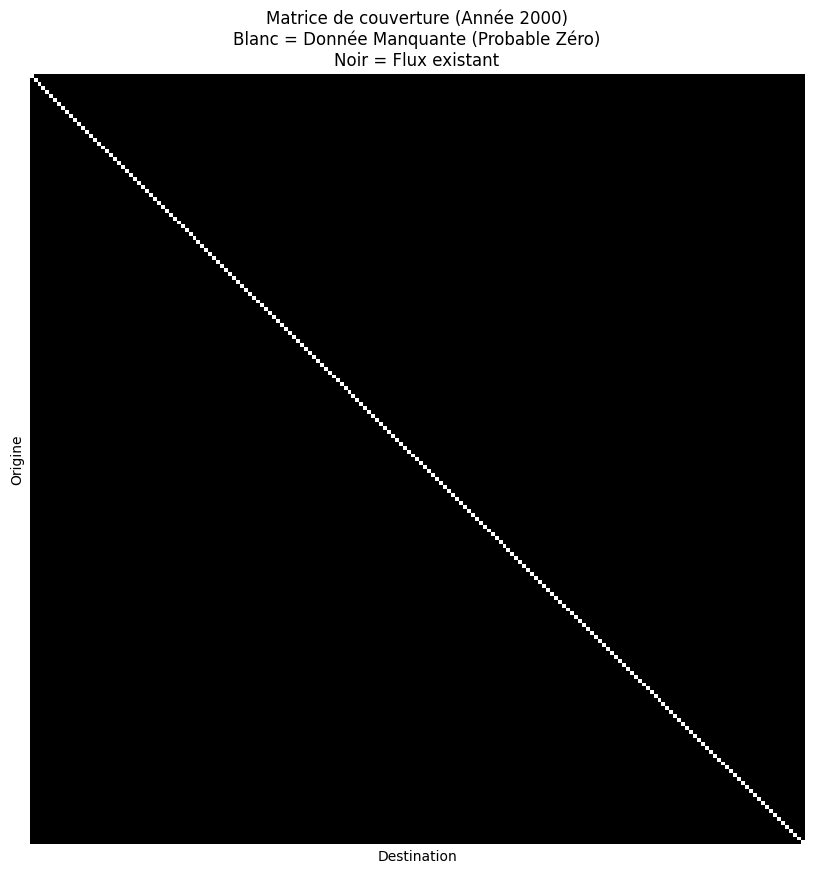

Taux de remplissage de la matrice en 2000 : 99.49%


In [23]:


# 1. On prend une année au milieu (2000)
df_2000 = df_main[df_main['year'] == 2000]

# 2. On crée la matrice Origine x Destination
# Si un couple existe, on met 1, sinon c'est vide (NaN)
matrix_2000 = df_2000.pivot(index='orig', columns='dest', values='flow')

# 3. On transforme en binaire pour le visuel : Présent vs Absent
# .notnull() va mettre True si la ligne existe, False si elle manque
sparsity = matrix_2000.notnull()

# 4. Le Graphique
plt.figure(figsize=(10, 10))
sns.heatmap(sparsity, cbar=False, cmap="binary", xticklabels=False, yticklabels=False)
plt.title("Matrice de couverture (Année 2000)\nBlanc = Donnée Manquante (Probable Zéro)\nNoir = Flux existant")
plt.xlabel("Destination")
plt.ylabel("Origine")
plt.show()

# 5. Calcul du taux de remplissage exact pour 2000
fill_rate = sparsity.sum().sum() / (sparsity.shape[0] * sparsity.shape[1])
print(f"Taux de remplissage de la matrice en 2000 : {fill_rate:.2%}")

In [25]:
# 1. IDENTIFIER LES LIGNES SANS PIB
missing_gdp = df_main[df_main['gdp_o'].isna()]

print(f"--- DIAGNOSTIC IMPACT PIB ---")
print(f"Lignes sans PIB Origine : {len(missing_gdp)} sur {len(df_main)} ({len(missing_gdp)/len(df_main):.1%})")

# 2. QUI SONT LES COUPABLES ?
# On compte combien d'années manquent par pays
suspects = missing_gdp.groupby('orig')['year'].nunique().sort_values(ascending=False)

print("\n--- TOP 10 PAYS SANS PIB (Nombre d'années manquantes sur 6) ---")
print(suspects.head(15))

# 3. EST-CE GRAVE ? (VOLUME DE MIGRANTS PERDUS)
# On compare le total des flux migratoires dans les lignes sans PIB vs le total mondial
total_flow_world = df_main['flow'].sum()
total_flow_lost  = missing_gdp['flow'].sum()

print("\n--- IMPACT RÉEL SUR LA PRÉDICTION ---")
print(f"Flux Total Mondial (Migrants) : {total_flow_world:,.0f}")
print(f"Flux concerné par les PIB manquants : {total_flow_lost:,.0f}")
print(f"PERTE EN VOLUME DE MIGRANTS : {total_flow_lost / total_flow_world:.2%}")

# 4. ANALYSE TEMPORELLE (Est-ce que c'est juste 1990 ?)
print("\n--- RÉPARTITION PAR ANNÉE (Lignes manquantes) ---")
print(missing_gdp['year'].value_counts().sort_index())

--- DIAGNOSTIC IMPACT PIB ---
Lignes sans PIB Origine : 12323 sur 231702 (5.3%)

--- TOP 10 PAYS SANS PIB (Nombre d'années manquantes sur 6) ---
orig
CLI    6
PRK    6
ESH    6
GUF    6
GLP    6
MTQ    6
REU    6
MYT    6
VIR    3
GUM    3
AFG    2
ERI    2
EST    1
LTU    1
MOZ    1
Name: year, dtype: int64

--- IMPACT RÉEL SUR LA PRÉDICTION ---
Flux Total Mondial (Migrants) : 482,262,028
Flux concerné par les PIB manquants : 3,861,379
PERTE EN VOLUME DE MIGRANTS : 0.80%

--- RÉPARTITION PAR ANNÉE (Lignes manquantes) ---
year
1990    3298
1995    2134
2000    1940
2005    1568
2010    1592
2015    1791
Name: count, dtype: int64


problème alphabétique!!! probablement dans le chargement de Gravity qui fait >1 Giga.

In [26]:
# On définit les blocs thématiques tels qu'on les a décrits dans le rapport
groups = {
    "Identifiants & Flux": ['orig', 'dest', 'flow', 'year'],
    "Démographie (ONU)": ['P_it', 'PSR_i', 'IMR_it'],
    "Urbanisation": ['urban_it', 'urban_jt'],
    "Géographie (CEPII)": ['D_ij', 'LB_ij'],
    "Économie retardée": ['gdp_o_lag'] 
}

def check_completeness(df, groups):
    total_rows = len(df)
    results = []
    
    for label, cols in groups.items():
        # On vérifie la présence des colonnes dans le DF pour éviter les erreurs
        existing_cols = [c for c in cols if c in df.columns]
        
        if not existing_cols:
            results.append([label, "Variables non trouvées", 0, "0.0 %"])
            continue
            
        # On calcule le nombre de lignes où TOUTES les variables du bloc sont présentes
        # C'est important car en économétrie, si une seule manque, la ligne saute.
        non_null_count = df[existing_cols].dropna().shape[0]
        pct = (non_null_count / total_rows) * 100
        
        results.append([
            label, 
            ", ".join(existing_cols), 
            non_null_count, 
            f"{pct:.2f} %"
        ])
    
    # Création du tableau final
    summary_df = pd.DataFrame(results, columns=[
        "Bloc thématique", "Variables testées", "Lignes complètes", "Taux de remplissage"
    ])
    
    return summary_df

# Utilisation (en supposant que ton DataFrame s'appelle df)
# stats_tableau = check_completeness(df, groups)
# print(stats_tableau)

In [27]:
stats_tableau = check_completeness(df_main, groups)
stats_tableau

,Bloc thématique,Variables testées,Lignes complètes,Taux de remplissage
0,Identifiants & Flux,"orig, dest, flow, year",231702,100.00 %
1,Démographie (ONU),"P_it, PSR_i, IMR_it",230526,99.49 %
2,Urbanisation,"urban_it, urban_jt",215490,93.00 %
3,Géographie (CEPII),"D_ij, LB_ij",212064,91.52 %
4,Économie retardée,gdp_o_lag,181370,78.28 %


In [55]:
all_features = ['flow', 'P_it', 'P_jt', 'D_ij', 'urban_it', 'gdp_o_lag']
final_sample_size = df_main[all_features].dropna().shape[0]

print(f"Nombre de lignes pour l'estimation finale : {final_sample_size}")
print(f"Taux de survie total : {(final_sample_size / 229350) * 100:.2f} %")

Nombre de lignes pour l'estimation finale : 198263
Taux de survie total : 86.45 %
